# Sprint 7 · Webinar 22 · Sesión Práctica

En esta sesión práctica trabajarás con el dataset `webinar19_customers_latam.csv`.

La idea es practicar con ejercicios **más directos y sencillos**, pensados para personas que están empezando a programar.


## Fecha

14 de diciembre de 2025


## Objetivos de la sesión práctica

Al finalizar la sesión, el/la estudiante podrá:

1. Reconocer la estructura básica de un dataset en Pandas.
2. Identificar columnas numéricas y categóricas.
3. Hacer una limpieza sencilla de valores faltantes o inválidos.
4. Usar bucles `for` y `while` en ejemplos cortos y fáciles de seguir.
5. Crear funciones simples para reutilizar tareas básicas.
6. Generar gráficos sencillos para entender el comportamiento de los datos.


## Agenda sugerida (100 minutos)

- Ejercicio 0 · Primer vistazo al dataset (10 min)
- Ejercicio 1 · Tipos de columnas y exploración básica (15 min)
- Ejercicio 2 · Limpieza sencilla de valores faltantes e inválidos (20 min)
- Ejercicio 3 · Filtros y resúmenes simples del dataset (15 min)
- Ejercicio 4 · Bucles `for` y `while` con ejemplos cortos (10 min)
- Ejercicio 5 · Funciones simples para reutilizar código (15 min)
- Ejercicio 6 · Gráficas básicas con `.plot()` (10 min)
- Ejercicio 7 · Git/GitHub: guardar y compartir el trabajo (5 min)


## Preparación del entorno (ejecuta primero)

Carga las librerías y el dataset base.

Este archivo tiene información de clientes en LatAm y varias columnas útiles para practicar:
- país y ciudad,
- plan del cliente,
- número de órdenes,
- gasto total,
- satisfacción,
- churn.

En esta práctica no vamos a construir lógica compleja. El foco será:
1. entender el dataset,
2. limpiar algunas columnas,
3. hacer ejercicios cortos,
4. visualizar resultados.


In [1]:
# Librerías base
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
from pathlib import Path

pd.set_option('display.max_columns', 50)

# Ruta flexible del dataset
possible_paths = [
    Path('webinar19_customers_latam.csv'),
    Path('/mnt/data/webinar19_customers_latam.csv')
]

for p in possible_paths:
    if p.exists():
        DATA_PATH = p
        break
else:
    raise FileNotFoundError('No se encontró webinar19_customers_latam.csv')

df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
df.head()


Shape: (5000, 20)


,customer_id,country,city,segment,signup_date,last_activity_date,device_os,plan_type,monthly_fee_usd,orders_90d,avg_order_value_usd,total_spend_90d_usd,support_tickets_90d,satisfaction_score,coupon_used,preferred_category,churned,age,monthly_fee_raw,last_activity_raw
0,C000001,México,CDMX,Retail,2024-08-23,2025-08-07,macOS,Basic,30.76,4,24.42,97.69,1,4.0,yes,Moda,0,27.0,30.76,2025-08-07
1,C000002,Argentina,Mendoza,SMB,2025-06-22,2025-12-26,iOS,Pro,65.80,6,26.20,157.18,2,4.3,yes,Moda,0,26.0,65.8,2025-12-26
2,C000003,Colombia,Medellín,Retail,2024-09-02,2024-12-02,Android,Plus,49.18,2,22.13,44.25,0,4.2,yes,Alimentos,1,27.0,49.18,2024-12-02
3,C000004,Colombia,Barranquilla,SMB,2025-11-01,2025-12-28,Linux,Basic,15.66,7,30.46,213.23,0,3.4,no,Hogar,0,45.0,15.66,2025-12-28
4,C000005,Colombia,Bogotá,Retail,2024-12-29,2025-09-20,Windows,Plus,NaN,4,38.71,154.85,0,4.1,yes,Belleza,0,45.0,NaN,2025-09-20


## Ejercicio 0 · Primer vistazo al dataset (10 min)

**Contexto:** antes de limpiar o analizar, primero debemos mirar el archivo y entender qué contiene.

### Tu reto
Responde en código:

1. Muestra cuántas filas y columnas tiene el dataset.
2. Muestra las primeras 5 filas.
3. Muestra los nombres de las columnas.
4. Elige 4 columnas que te parezcan importantes y muestra solo esas columnas con `head()`.

### Pistas
- Usa `df.shape`.
- Usa `df.head()`.
- Usa `df.columns`.


In [2]:
# TU CÓDIGO AQUÍ (Ejercicio 0)

# 1) Ver tamaño del dataset
# print(df.shape)

# 2) Ver primeras filas
# display(df.head())

# 3) Ver columnas
# print(df.columns.tolist())

# 4) Mostrar 4 columnas importantes
# cols = ["customer_id", "country", "plan_type", "churned"]
# display(df[cols].head())


#### Solución:


In [3]:
# SOLUCIÓN (Ejercicio 0)

print("Filas y columnas:", df.shape)

display(df.head())

print("Columnas del dataset:")
print(df.columns.tolist())

cols = ["customer_id", "country", "plan_type", "churned"]
display(df[cols].head())


Filas y columnas: (5000, 20)


,customer_id,country,city,segment,signup_date,last_activity_date,device_os,plan_type,monthly_fee_usd,orders_90d,avg_order_value_usd,total_spend_90d_usd,support_tickets_90d,satisfaction_score,coupon_used,preferred_category,churned,age,monthly_fee_raw,last_activity_raw
0,C000001,México,CDMX,Retail,2024-08-23,2025-08-07,macOS,Basic,30.76,4,24.42,97.69,1,4.0,yes,Moda,0,27.0,30.76,2025-08-07
1,C000002,Argentina,Mendoza,SMB,2025-06-22,2025-12-26,iOS,Pro,65.80,6,26.20,157.18,2,4.3,yes,Moda,0,26.0,65.8,2025-12-26
2,C000003,Colombia,Medellín,Retail,2024-09-02,2024-12-02,Android,Plus,49.18,2,22.13,44.25,0,4.2,yes,Alimentos,1,27.0,49.18,2024-12-02
3,C000004,Colombia,Barranquilla,SMB,2025-11-01,2025-12-28,Linux,Basic,15.66,7,30.46,213.23,0,3.4,no,Hogar,0,45.0,15.66,2025-12-28
4,C000005,Colombia,Bogotá,Retail,2024-12-29,2025-09-20,Windows,Plus,NaN,4,38.71,154.85,0,4.1,yes,Belleza,0,45.0,NaN,2025-09-20


Columnas del dataset:
['customer_id', 'country', 'city', 'segment', 'signup_date', 'last_activity_date', 'device_os', 'plan_type', 'monthly_fee_usd', 'orders_90d', 'avg_order_value_usd', 'total_spend_90d_usd', 'support_tickets_90d', 'satisfaction_score', 'coupon_used', 'preferred_category', 'churned', 'age', 'monthly_fee_raw', 'last_activity_raw']


,customer_id,country,plan_type,churned
0,C000001,México,Basic,0
1,C000002,Argentina,Pro,0
2,C000003,Colombia,Plus,1
3,C000004,Colombia,Basic,0
4,C000005,Colombia,Plus,0


## Ejercicio 1 · Tipos de columnas y exploración básica (15 min)

### Objetivo
- Identificar columnas numéricas y categóricas.
- Revisar valores faltantes de forma sencilla.
- Obtener un resumen rápido del dataset.

### Tu reto
1. Crear una lista de columnas numéricas.
2. Crear una lista de columnas categóricas.
3. Mostrar cuántos valores faltantes hay en cada columna.
4. Usar `describe()` en las columnas numéricas.

### Pistas
- Usa `df.select_dtypes()`.
- Usa `df.isna().sum()`.
- Usa `describe()`.


In [4]:
# TU CÓDIGO AQUÍ (Ejercicio 1)

# num_cols = ...
# cat_cols = ...

# print("Numéricas:", num_cols)
# print("Categóricas:", cat_cols)

# missing = ...
# display(missing)

# display(df[num_cols].describe().T)


#### Solución:


In [5]:
# SOLUCIÓN (Ejercicio 1)

num_cols = df.select_dtypes(include=["number"]).columns.tolist()
cat_cols = df.select_dtypes(include=["object"]).columns.tolist()

print("Columnas numéricas:")
print(num_cols)
print()
print("Columnas categóricas:")
print(cat_cols)

missing = df.isna().sum().sort_values(ascending=False)
display(missing)

display(df[num_cols].describe().T)


Columnas numéricas:
['monthly_fee_usd', 'orders_90d', 'avg_order_value_usd', 'total_spend_90d_usd', 'support_tickets_90d', 'satisfaction_score', 'churned', 'age']

Columnas categóricas:
['customer_id', 'country', 'city', 'segment', 'signup_date', 'last_activity_date', 'device_os', 'plan_type', 'coupon_used', 'preferred_category', 'monthly_fee_raw', 'last_activity_raw']


age                    296
monthly_fee_raw        169
monthly_fee_usd        150
country                 50
city                    50
last_activity_raw       13
segment                  0
customer_id              0
plan_type                0
signup_date              0
device_os                0
last_activity_date       0
total_spend_90d_usd      0
avg_order_value_usd      0
orders_90d               0
support_tickets_90d      0
preferred_category       0
coupon_used              0
satisfaction_score       0
churned                  0
dtype: int64

,count,mean,std,min,25%,50%,75%,max
monthly_fee_usd,4850.0,45.145140,34.012812,-10.00,24.9300,34.875,51.800,191.86
orders_90d,5000.0,4.379400,3.020742,0.00,2.0000,4.000,6.000,23.00
avg_order_value_usd,5000.0,31.830598,19.114518,3.80,18.8600,27.200,39.465,233.53
total_spend_90d_usd,5000.0,136.339096,140.361732,-607.51,53.6375,99.540,176.775,3505.99
support_tickets_90d,5000.0,0.654200,0.802715,0.00,0.0000,0.000,1.000,6.00
satisfaction_score,5000.0,4.081060,0.566981,1.90,3.7000,4.100,4.500,5.00
churned,5000.0,0.511600,0.499915,0.00,0.0000,1.000,1.000,1.00
age,4704.0,35.914753,63.595603,-5.00,26.0000,32.000,38.000,999.00


## Ejercicio 2 · Limpieza sencilla de valores faltantes e inválidos (20 min)

### Objetivo
Hacer una limpieza básica, paso a paso, sin reglas avanzadas.

### Tu reto
1. Crear una copia del dataset llamada `df_clean`.
2. Reemplazar valores vacíos de `country` y `city` por `"Unknown"`.
3. Convertir `monthly_fee_raw` a número en una nueva columna llamada `monthly_fee_clean`.
4. Convertir `last_activity_raw` a fecha en una nueva columna llamada `last_activity_clean`.
5. Crear una columna `age_clean` donde las edades menores o iguales a 0 se cambien por `NaN`.

### Pistas
- Usa `df.copy()`.
- Usa `.fillna("Unknown")`.
- Usa `pd.to_numeric(..., errors="coerce")`.
- Usa `pd.to_datetime(..., errors="coerce")`.
- Usa `.loc[...]` para cambiar valores.


In [6]:
# TU CÓDIGO AQUÍ (Ejercicio 2)

# df_clean = df.copy()

# df_clean["country"] = ...
# df_clean["city"] = ...

# df_clean["monthly_fee_clean"] = ...
# df_clean["last_activity_clean"] = ...

# df_clean["age_clean"] = df_clean["age"]
# df_clean.loc[df_clean["age_clean"] <= 0, "age_clean"] = np.nan

# display(df_clean[["country", "city", "monthly_fee_raw", "monthly_fee_clean",
#                   "last_activity_raw", "last_activity_clean", "age", "age_clean"]].head(10))


#### Solución:


In [7]:
# SOLUCIÓN (Ejercicio 2)

df_clean = df.copy()

# Reemplazar faltantes simples
# También limpiamos textos vacíos para que queden como Unknown
for col in ["country", "city"]:
    df_clean[col] = df_clean[col].fillna("Unknown")
    df_clean[col] = df_clean[col].replace("", "Unknown")

# Convertir texto a número
df_clean["monthly_fee_clean"] = pd.to_numeric(df_clean["monthly_fee_raw"], errors="coerce")

# Convertir texto a fecha
df_clean["last_activity_clean"] = pd.to_datetime(df_clean["last_activity_raw"], errors="coerce")

# Limpiar edad
df_clean["age_clean"] = df_clean["age"]
df_clean.loc[df_clean["age_clean"] <= 0, "age_clean"] = np.nan

display(df_clean[[
    "country", "city", "monthly_fee_raw", "monthly_fee_clean",
    "last_activity_raw", "last_activity_clean", "age", "age_clean"
]].head(10))


,country,city,monthly_fee_raw,monthly_fee_clean,last_activity_raw,last_activity_clean,age,age_clean
0,México,CDMX,30.76,30.76,2025-08-07,2025-08-07,27.0,27.0
1,Argentina,Mendoza,65.8,65.80,2025-12-26,2025-12-26,26.0,26.0
2,Colombia,Medellín,49.18,49.18,2024-12-02,2024-12-02,27.0,27.0
3,Colombia,Barranquilla,15.66,15.66,2025-12-28,2025-12-28,45.0,45.0
4,Colombia,Bogotá,NaN,NaN,2025-09-20,2025-09-20,45.0,45.0
5,Perú,Trujillo,45.53,45.53,2026-07-17,2026-07-17,28.0,28.0
6,Perú,Arequipa,23.89,23.89,2025-02-18,2025-02-18,37.0,37.0
7,México,CDMX,50.65,50.65,2026-04-19,2026-04-19,NaN,NaN
8,Colombia,Bogotá,47.07,47.07,2025-11-19,2025-11-19,44.0,44.0
9,Argentina,Córdoba,36.58,36.58,2025-12-17,2025-12-17,46.0,46.0


## Ejercicio 3 · Filtros y resúmenes simples del dataset (15 min)

### Objetivo
Usar filtros sencillos y obtener métricas básicas sin transformaciones avanzadas.

### Tu reto
1. Mostrar solo los clientes de Colombia.
2. Mostrar solo los clientes con `churned == 1`.
3. Calcular el promedio de `monthly_fee_clean`.
4. Calcular el promedio de `age_clean`.
5. Contar cuántos clientes hay por `plan_type`.

### Pistas
- Usa filtros como `df_clean[df_clean["country"] == "Colombia"]`.
- Usa `.mean()`.
- Usa `.value_counts()`.


In [8]:
# TU CÓDIGO AQUÍ (Ejercicio 3)

# clientes_colombia = ...
# clientes_churn = ...

# print("Promedio monthly_fee_clean:", ...)
# print("Promedio age_clean:", ...)

# planes = ...
# display(planes)


#### Solución:


In [9]:
# SOLUCIÓN (Ejercicio 3)

clientes_colombia = df_clean[df_clean["country"] == "Colombia"]
clientes_churn = df_clean[df_clean["churned"] == 1]

print("Clientes de Colombia:", len(clientes_colombia))
print("Clientes con churn:", len(clientes_churn))

print("Promedio monthly_fee_clean:", round(df_clean["monthly_fee_clean"].mean(), 2))
print("Promedio age_clean:", round(df_clean["age_clean"].mean(), 2))

planes = df_clean["plan_type"].value_counts()
display(planes)


Clientes de Colombia: 1734
Clientes con churn: 2558
Promedio monthly_fee_clean: 45.13
Promedio age_clean: 36.24


plan_type
Basic         2514
Plus          1364
Pro            897
Enterprise     225
Name: count, dtype: int64

## Ejercicio 4 · Bucles (`for` y `while`) con ejemplos cortos (10 min)

### Objetivo
Practicar bucles en tareas pequeñas y fáciles de leer.

### Tu reto
1. Usa un `for` para recorrer una lista de columnas y mostrar cuántos valores faltantes tiene cada una.
2. Usa un `while` para imprimir los primeros 5 `customer_id` del dataset.

### Pistas
- Puedes usar una lista como `cols = ["country", "city", "monthly_fee_clean", "age_clean"]`.
- Para el `while`, crea una variable `i = 0` y aumenta con `i = i + 1`.


In [10]:
# TU CÓDIGO AQUÍ (Ejercicio 4)

# cols = ["country", "city", "monthly_fee_clean", "age_clean"]

# for col in cols:
#     print(col, df_clean[col].isna().sum())

# i = 0
# while i < 5:
#     print(df_clean.loc[i, "customer_id"])
#     i = i + 1


#### Solución:


In [11]:
# SOLUCIÓN (Ejercicio 4)

cols = ["country", "city", "monthly_fee_clean", "age_clean"]

print("Valores faltantes por columna:")
for col in cols:
    print(f"{col}: {df_clean[col].isna().sum()}")

print()
print("Primeros 5 customer_id usando while:")
i = 0
while i < 5:
    print(df_clean.loc[i, "customer_id"])
    i = i + 1


Valores faltantes por columna:
country: 0
city: 0
monthly_fee_clean: 184
age_clean: 336

Primeros 5 customer_id usando while:
C000001
C000002
C000003
C000004
C000005


## Ejercicio 5 · Funciones simples para reutilizar código (15 min)

### Objetivo
Crear funciones cortas, con una sola responsabilidad.

### Tu reto
Escribe dos funciones sencillas:

1. `mostrar_promedio(columna)`  
   - recibe el nombre de una columna numérica  
   - devuelve el promedio de esa columna en `df_clean`

2. `contar_por_categoria(columna)`  
   - recibe el nombre de una columna categórica  
   - devuelve el conteo de valores de esa columna

Luego usa ambas funciones con:
- `monthly_fee_clean`
- `plan_type`

### Pistas
- Dentro de la función puedes usar `df_clean[columna].mean()`.
- Para contar categorías usa `value_counts()`.


In [12]:
# TU CÓDIGO AQUÍ (Ejercicio 5)

# def mostrar_promedio(columna):
#     ...

# def contar_por_categoria(columna):
#     ...

# print(mostrar_promedio("monthly_fee_clean"))
# display(contar_por_categoria("plan_type"))


#### Solución:


In [13]:
# SOLUCIÓN (Ejercicio 5)

def mostrar_promedio(columna):
    return df_clean[columna].mean()


def contar_por_categoria(columna):
    return df_clean[columna].value_counts()


print("Promedio de monthly_fee_clean:", round(mostrar_promedio("monthly_fee_clean"), 2))

display(contar_por_categoria("plan_type"))


Promedio de monthly_fee_clean: 45.13


plan_type
Basic         2514
Plus          1364
Pro            897
Enterprise     225
Name: count, dtype: int64

## Ejercicio 6 · Gráficas básicas con `.plot()` (10 min)

### Objetivo
Crear gráficos sencillos para comenzar a interpretar el dataset.

### Tu reto
1. Hacer un histograma de `monthly_fee_clean`.
2. Hacer un gráfico de barras con la cantidad de clientes por `plan_type`.
3. Hacer un boxplot de `age_clean`.
4. Escribir una interpretación rápida de lo que observas.

### Pistas
- Usa `.plot(kind="hist")`.
- Usa `.value_counts().plot(kind="bar")`.
- Usa `.plot(kind="box")`.


In [14]:
# TU CÓDIGO AQUÍ (Ejercicio 6)

# df_clean["monthly_fee_clean"].dropna().plot(kind="hist", bins=20, figsize=(8,4), title="Histograma de tarifa mensual")
# plt.show()

# df_clean["plan_type"].value_counts().plot(kind="bar", figsize=(8,4), title="Clientes por plan")
# plt.show()

# df_clean[["age_clean"]].plot(kind="box", figsize=(6,4), title="Boxplot de edad")
# plt.show()


#### Solución:


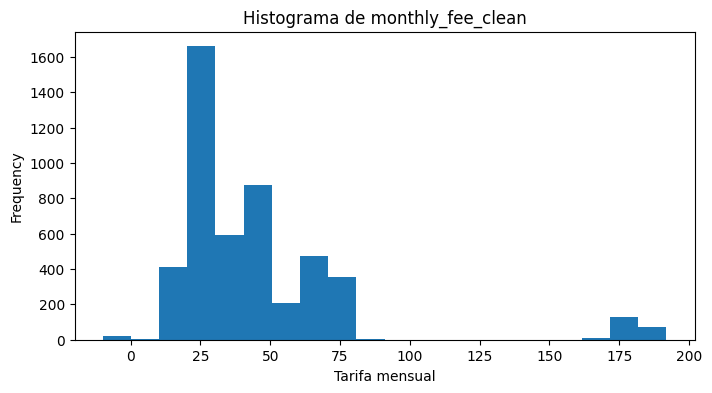

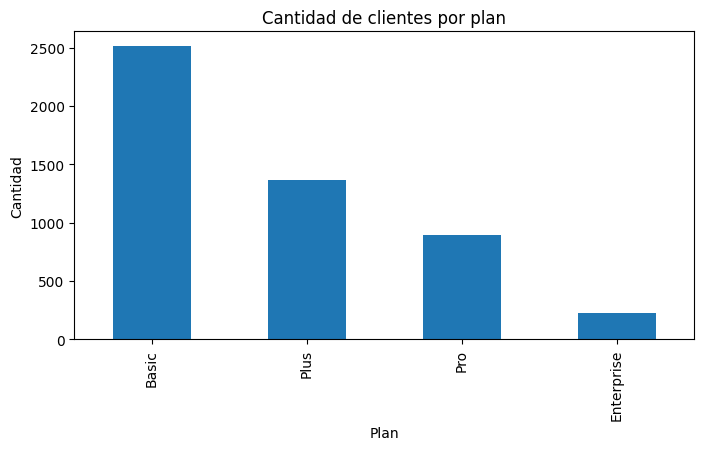

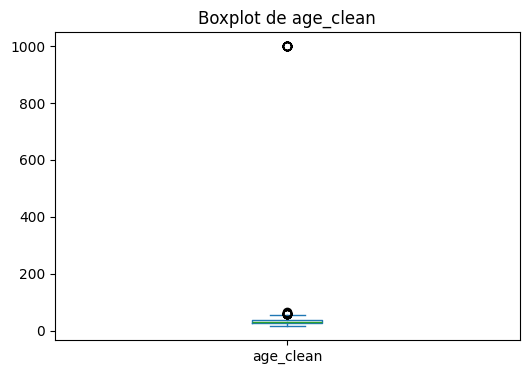

Interpretación rápida:
- La tarifa mensual se concentra en ciertos rangos de valor.
- Algunos planes tienen más clientes que otros.
- El boxplot ayuda a detectar edades alejadas del centro de la distribución.


In [15]:
# SOLUCIÓN (Ejercicio 6)

# Histograma
ax = df_clean["monthly_fee_clean"].dropna().plot(
    kind="hist",
    bins=20,
    figsize=(8, 4),
    title="Histograma de monthly_fee_clean"
)
ax.set_xlabel("Tarifa mensual")
plt.show()

# Barras por plan
ax = df_clean["plan_type"].value_counts().plot(
    kind="bar",
    figsize=(8, 4),
    title="Cantidad de clientes por plan"
)
ax.set_xlabel("Plan")
ax.set_ylabel("Cantidad")
plt.show()

# Boxplot de edad
df_clean[["age_clean"]].plot(
    kind="box",
    figsize=(6, 4),
    title="Boxplot de age_clean"
)
plt.show()

print("Interpretación rápida:")
print("- La tarifa mensual se concentra en ciertos rangos de valor.")
print("- Algunos planes tienen más clientes que otros.")
print("- El boxplot ayuda a detectar edades alejadas del centro de la distribución.")


## Ejercicio 7 · Git/GitHub: crear repo, clonar, primer commit (5 min)

### Objetivo
Guardar el trabajo de la clase en un repositorio.

### Checklist (paso a paso)

1. Crear un repositorio en GitHub  
   - Nombre sugerido: `sprint7-webinar22-practico`

2. Clonar en tu computador:
```bash
git clone <URL_DEL_REPO>
cd sprint7-webinar22-practico
```

3. Copiar dentro del repo:
- `Sprint07_Webinar22_Practico_principiantes.ipynb`
- `webinar19_customers_latam.csv`

4. Hacer el primer commit:
```bash
git add .
git commit -m "Webinar 22: práctica para principiantes"
git push
```


## Take aways (resumen extendido)

1. Antes de analizar, primero se observa el dataset: tamaño, columnas y primeros registros.
2. Separar columnas numéricas y categóricas ayuda a decidir qué operaciones aplicar.
3. La limpieza básica puede comenzar con pasos simples: rellenar vacíos, convertir tipos y corregir valores inválidos.
4. Los bucles `for` y `while` sirven para automatizar tareas pequeñas y repetitivas.
5. Las funciones ayudan a reutilizar código sin repetir instrucciones.
6. Las gráficas básicas permiten comenzar a interpretar los datos de una forma visual.


## Cierre

**Repaso final:**
- Exploramos un dataset real con Pandas.
- Limpiamos algunas columnas con pasos sencillos.
- Practicamos bucles y funciones en ejemplos cortos.
- Creamos gráficas básicas con `.plot()`.

**Reflexión:**
- ¿Qué parte te pareció más fácil: explorar, limpiar o graficar?
- ¿Qué columna del dataset te gustaría analizar más a fondo en otra sesión?


## Siguientes pasos

- Repite los ejercicios cambiando las columnas usadas.
- Intenta crear una nueva gráfica con otra variable numérica.
- Sube tu notebook a GitHub como evidencia de práctica.
- En la próxima sesión podrás profundizar en segmentación y análisis más detallado.
